In [1]:
import pandas as pd
from transformers import pipeline, AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
datos = pd.read_csv("comentarios_post_reddit.csv")

# Verificar estructura
print(datos.head())

# Solo columna comentario
comentarios = datos["comentario"].dropna()

       usuario                                         comentario  score  \
0    [deleted]  Judging by the fact she was jumping back i thi...    101   
1      Solusai  thats... not the issue\n\nthe issue is I hfb'd...     16   
2  pinyata_pie  Yeah but if they mistime the 2k just a lil the...     59   
3      Solusai  there is no mistiming it this shit is that min...    -40   
4    [deleted]  I gotta disagree. While Hammer Fall is super m...     37   

                 fecha  
0  2025-06-19 07:14:49  
1  2025-06-19 07:20:56  
2  2025-06-19 07:44:14  
3  2025-06-19 07:45:36  
4  2025-06-19 11:02:32  


In [3]:
classifier = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

tokenizer = AutoTokenizer.from_pretrained(
    "nlptown/bert-base-multilingual-uncased-sentiment"
)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [4]:
def dividir_en_chunks(texto, max_length=50):
    tokens = tokenizer(
        texto,
        truncation=True,
        padding=False,
        max_length=max_length,
        return_overflowing_tokens=True
    )

    input_ids = tokens["input_ids"]

    chunks = [
        tokenizer.decode(chunk, skip_special_tokens=True)
        for chunk in input_ids
    ]

    return chunks


In [5]:
resultados = []

for comentario in comentarios:
    chunks = dividir_en_chunks(str(comentario))

    for chunk in chunks:
        resultado = classifier(chunk)[0]
        resultados.append(resultado)

In [6]:
df_resultados = pd.DataFrame(resultados)

# Convertir "5 stars" -> 5
df_resultados["estrellas"] = df_resultados["label"].str.extract(r"(\d)").astype(int)

print(df_resultados.head())

     label     score  estrellas
0  3 stars  0.344294          3
1  3 stars  0.459988          3
2  2 stars  0.441483          2
3   1 star  0.547577          1
4  2 stars  0.321785          2


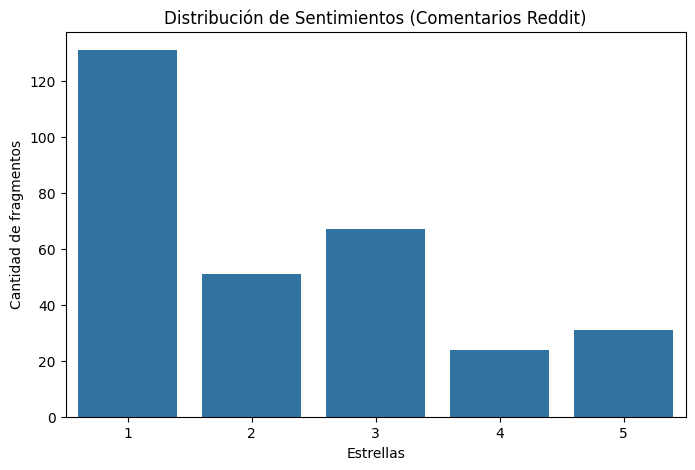

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(x="estrellas", data=df_resultados)

plt.title("Distribución de Sentimientos (Comentarios Reddit)")
plt.xlabel("Estrellas")
plt.ylabel("Cantidad de fragmentos")

plt.show()

##Analisis


Como vemos en la grafica la mayoria de comentarios son negativos, siendo la gran mayoria de comentarios de una estrella, esto debido a que se seleccionaron los comentarios sobre un post de odio hacia un personaje de un juego competitivo, aqui se muestra que los usuarios coinciden en su mayoria con el autor del post o algunos defendiendose a ellos mismo y a su personaje favorito

